In [1]:
## NLP Lab

In [37]:
from collections import Counter
import matplotlib.pyplot as plt
import spacy
nlp = spacy.load("en_core_web_sm")

In [3]:
original_sentance = "When the setting sun hits Horsetail Fall, it creates an optical illusion that transforms the water coming off the rocks into what looks like molten lava pouring down the granite face of El Capitan. According to the US National Park Service, the fiery effect appears only in mid to late February, and only on clear evenings when the waterfall is flowing. Horsetail Fall, in California\'s Yosemite National Park, typically runs only during winter, and even slight haze or cloud cover can greatly diminish the display, according to the NPS."
print(original_sentance)

When the setting sun hits Horsetail Fall, it creates an optical illusion that transforms the water coming off the rocks into what looks like molten lava pouring down the granite face of El Capitan. According to the US National Park Service, the fiery effect appears only in mid to late February, and only on clear evenings when the waterfall is flowing. Horsetail Fall, in California's Yosemite National Park, typically runs only during winter, and even slight haze or cloud cover can greatly diminish the display, according to the NPS.


In [4]:
nlp_sentance = nlp(original_sentance)

In [5]:
## Task 1: Tokenise the senetance

In [6]:
for token in nlp_sentance:
    print (token.text, token.pos_, end = " | ")

When SCONJ | the DET | setting VERB | sun NOUN | hits VERB | Horsetail PROPN | Fall PROPN | , PUNCT | it PRON | creates VERB | an DET | optical ADJ | illusion NOUN | that PRON | transforms VERB | the DET | water NOUN | coming VERB | off ADP | the DET | rocks NOUN | into ADP | what PRON | looks VERB | like ADP | molten ADJ | lava NOUN | pouring VERB | down ADP | the DET | granite NOUN | face NOUN | of ADP | El PROPN | Capitan PROPN | . PUNCT | According VERB | to ADP | the DET | US PROPN | National PROPN | Park PROPN | Service PROPN | , PUNCT | the DET | fiery ADJ | effect NOUN | appears VERB | only ADV | in ADP | mid ADJ | to ADP | late ADJ | February PROPN | , PUNCT | and CCONJ | only ADV | on ADP | clear ADJ | evenings NOUN | when SCONJ | the DET | waterfall NOUN | is AUX | flowing VERB | . PUNCT | Horsetail PROPN | Fall PROPN | , PUNCT | in ADP | California PROPN | 's PART | Yosemite PROPN | National PROPN | Park PROPN | , PUNCT | typically ADV | runs VERB | only ADV | during ADP | 

In [7]:
## Task 2: Access named entities, then identify noun chunk it belongs to

In [8]:
for entity in nlp_sentance.ents:
    print(entity, entity.label_)

Horsetail Fall FAC
El Capitan ORG
the US National Park Service ORG
mid to late February DATE
Horsetail Fall PERSON
California GPE
Yosemite National Park FAC
winter DATE
NPS ORG


In [9]:
for noun in nlp_sentance.noun_chunks:
    print(noun)

the setting sun
Horsetail Fall
it
an optical illusion
that
the water
the rocks
what
molten lava
the granite face
El Capitan
the US National Park Service
the fiery effect
late February
clear evenings
the waterfall
Horsetail Fall
California's Yosemite National Park
winter
even slight haze or cloud cover
the display
the NPS


In [10]:
## Format and list the data together

In [11]:
col1 = "Named Entity"
col2 = "Label"
col3 = "Noun Chunk"

sentance_noun_chunks = list(nlp_sentance.noun_chunks)

# Header
print(f"{col1:30} {col2:12} {col3:35}")
print("-" * 80)

for entity in nlp_sentance.ents:
    chunk_for_entity: None
    for chunk in sentance_noun_chunks:
        # Check if the entity is in the noun chunk
        if entity.start >= chunk.start and entity.end <= chunk.end:
            chunk_for_entity = chunk.text
            # breaking as will only be one instance
            break

    print(f"{entity.text:30} {entity.label_:12} {chunk_for_entity:35}")

Named Entity                   Label        Noun Chunk                         
--------------------------------------------------------------------------------
Horsetail Fall                 FAC          Horsetail Fall                     
El Capitan                     ORG          El Capitan                         
the US National Park Service   ORG          the US National Park Service       
mid to late February           DATE         the US National Park Service       
Horsetail Fall                 PERSON       Horsetail Fall                     
California                     GPE          California's Yosemite National Park
Yosemite National Park         FAC          California's Yosemite National Park
winter                         DATE         winter                             
NPS                            ORG          the NPS                            


In [12]:
## Track the prefix and suffixes of the entities

In [22]:
# Pick a prefix/suffix length to use
ix_char_length = 3

prefix_list = [];
suffix_list = [];

for entity in nlp_sentance.ents:
    if (len(entity.text) >= ix_char_length):
        prefix_list.append(entity.text[:ix_char_length].lower())
        suffix_list.append(entity.text[-ix_char_length:].lower())

# print(prefix_list)
# print(suffix_list)

prefix_list_counts = Counter(prefix_list)
suffix_list_counts = Counter(suffix_list)

print("Prefix - Top 2")
print("-" * 80)
for item, count in prefix_list_counts.most_common(2):
    print(f"{item} {count}")

print("\n")
print("Suffix - Top 2")
print("-" * 80)
for item, count in suffix_list_counts.most_common(2):
    print(f"{item} {count}")




Prefix - Top 2
--------------------------------------------------------------------------------
hor 2
el  1


Suffix - Top 2
--------------------------------------------------------------------------------
all 2
tan 1


In [ ]:
## Entity Stats Count

In [35]:

person_label_count = 0
org_label_count = 0
gpe_label_count = 0


for entity in nlp_sentance.ents:
    if (entity.label_ == "PERSON"):
        person_label_count += 1
    elif (entity.label_ == "ORG"):
        org_label_count += 1
    elif (entity.label_ == "GPE"):
        gpe_label_count += 1

print('Summary')
print("-" * 80)
print(f"Tokens: {len(nlp_sentance)}")
print(f"PERSON: {person_label_count}")
print(f"ORG: {org_label_count}")
print(f"GPE: {gpe_label_count}")
print(f"Noun chunks: {len(sentance_noun_chunks)}")

Summary
--------------------------------------------------------------------------------
Tokens: 100
PERSON: 1
ORG: 3
GPE: 1
Tokens: 22


In [ ]:
## Visualisation

<BarContainer object of 3 artists>

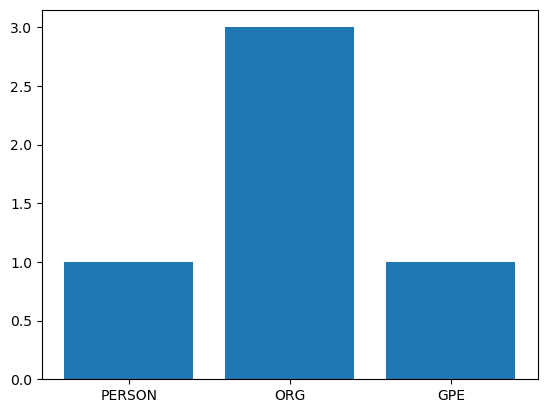

In [39]:
entity_types = ["PERSON", "ORG", "GPE"]
counts = [person_label_count, org_label_count, gpe_label_count]

plt.bar(entity_types, counts)